Synthetic Energy Dataset Generated Successfully!
                       energy_MW
Datetime                        
2020-01-01 00:00:00  1866.927838
2020-01-01 01:00:00  2070.956167
2020-01-01 02:00:00  2046.312605
2020-01-01 03:00:00  2432.188648
2020-01-01 04:00:00  2182.189143


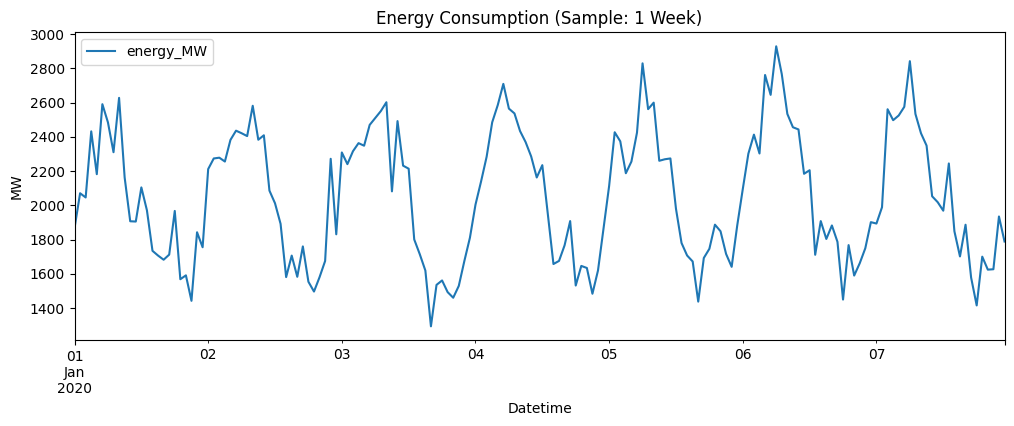

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a datetime range for 4 years with hourly frequency
dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='h')
n = len(dates)

# 2. Simulate realistic energy patterns
# Base load + Daily cycle + Yearly seasonality + Random noise
base = 2000 
daily_cycle = 500 * np.sin(2 * np.pi * dates.hour / 24)
yearly_cycle = 1000 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 150, n)

energy_values = base + daily_cycle + yearly_cycle + noise

# 3. Create the main DataFrame
df = pd.DataFrame({'energy_MW': energy_values}, index=dates)
df.index.name = 'Datetime'

print("Synthetic Energy Dataset Generated Successfully!")
print(df.head())

# A weeks visuals to check the cirle
df.iloc[:24*7].plot(figsize=(12, 4), title='Energy Consumption (Sample: 1 Week)')
plt.ylabel('MW')
plt.show()
    

In [9]:
def create_time_features(df):
    """
    Creates time series features based on datetime index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # Lag Features: Use past values to predict the future
    # lag_24h represents the energy consumption exactly 1 day ago
    df['lag_24h'] = df['energy_MW'].shift(24)
    # lag_7d represents the energy consumption exactly 1 week ago
    df['lag_7d'] = df['energy_MW'].shift(24*7)
    
    # Remove rows with NaN values caused by shifting
    return df.dropna()

# Apply the feature engineering function
df_features = create_time_features(df)

In [10]:
# Train/test (Time-based split)
import xgboost as xgb

train = df_features.loc[df_features.index < '2023-01-01']
test = df_features.loc[df_features.index >= '2023-01-01']


X_train = train.drop('energy_MW', axis=1)
y_train = train['energy_MW']

X_test = test.drop('energy_MW', axis=1)
y_test = test['energy_MW']

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

[0]	validation_0-rmse:764.27152
[100]	validation_0-rmse:170.25389
[200]	validation_0-rmse:168.46755
[299]	validation_0-rmse:168.17225


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# XGBoost predictions
xgb_preds = model.predict(X_test)

# Metrics
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = mean_squared_error(y_test, xgb_preds) ** 0.5
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Results
MAE: 134.20962101925286
RMSE: 168.17224629966802
R2: 0.9559918552910253


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Linear Regression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

# Metrics
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression Results
MAE: 149.1504050687287
RMSE: 187.27488040691264
R2: 0.9454262915387385


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MLP Metrics
mlp_mae = mean_absolute_error(y_test, mlp_preds)
mlp_rmse = mean_squared_error(y_test, mlp_preds) ** 0.5
mlp_r2 = r2_score(y_test, mlp_preds)

print("MLP Regressor Results")
print("MAE:", mlp_mae)
print("RMSE:", mlp_rmse)
print("R2:", mlp_r2)

MLP Regressor Results
MAE: 148.30473822719424
RMSE: 185.70971124736877
R2: 0.9463346904031565


In [25]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'XGBoost',
        'MLP Regressor'
    ],
    'MAE': [
        lr_mae,
        xgb_mae,
        mlp_mae
    ],
    'RMSE': [
        lr_rmse,
        xgb_rmse,
        mlp_rmse
    ],
    'R2': [
        lr_r2,
        xgb_r2,
        mlp_r2
    ]
})

results = results.sort_values(by='RMSE')

print(results)

               Model         MAE        RMSE        R2
1            XGBoost  134.209621  168.172246  0.955992
2      MLP Regressor  148.304738  185.709711  0.946335
0  Linear Regression  149.150405  187.274880  0.945426


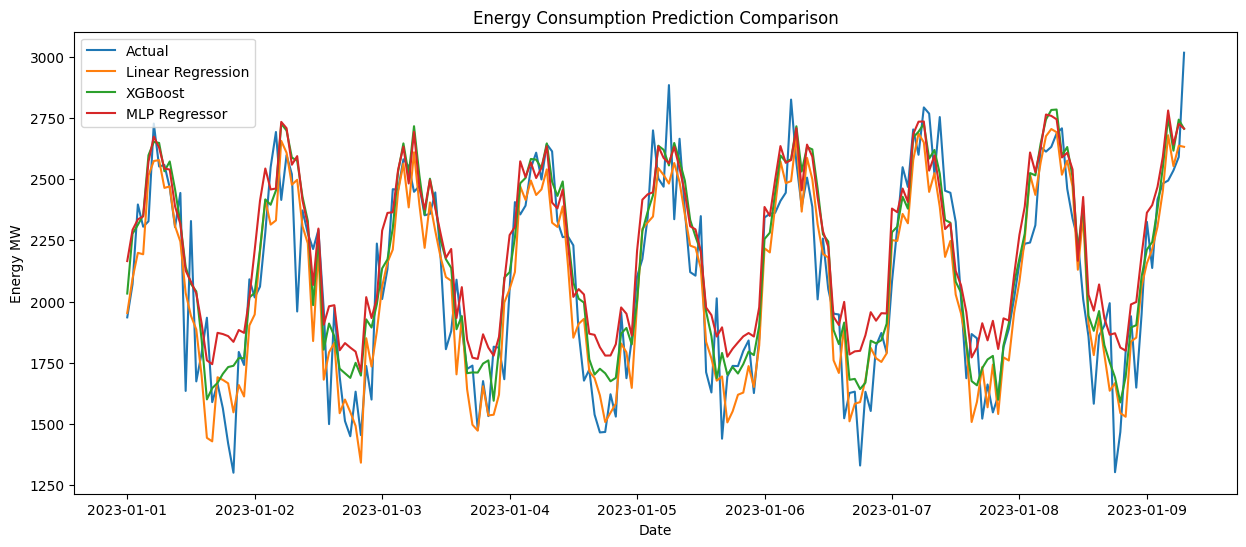

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Actual values
plt.plot(
    y_test.index[:200],
    y_test.values[:200],
    label='Actual'
)

# Linear Regression
plt.plot(
    y_test.index[:200],
    lr_preds[:200],
    label='Linear Regression'
)

# XGBoost
plt.plot(
    y_test.index[:200],
    xgb_preds[:200],
    label='XGBoost'
)

# MLP
plt.plot(
    y_test.index[:200],
    mlp_preds[:200],
    label='MLP Regressor'
)

plt.title("Energy Consumption Prediction Comparison")
plt.xlabel("Date")
plt.ylabel("Energy MW")

plt.legend()

plt.show()